# Plotting a Visium dataset

This tutorial shows how to use `spatialdata-plot` on a real 10x Genomics Visium experiment: render the H&E tissue image, render the spots, overlay them, color spots by gene expression and by cluster, then build a publication-style figure.

**Dataset**: a Visium H&E mouse brain section, downloaded by `squidpy.datasets.visium_hne_sdata` from the scverse example data host. The download (~400 MB) is cached after the first run.

**Credit**: the example progression here (H&E + spots, gene-expression overlay, outline styling) was originally curated by [@asarigun] in [scverse/spatialdata-plot#590].

[@asarigun]: https://github.com/asarigun
[scverse/spatialdata-plot#590]: https://github.com/scverse/spatialdata-plot/pull/590

## Loading the dataset

`squidpy.datasets.visium_hne_sdata()` returns a ready-to-plot `SpatialData` object containing the multi-resolution H&E image, the spot polygons, and the linked `AnnData` table.

In [3]:
import squidpy as sq

import spatialdata_plot  # noqa: F401  (registers the .pl accessor)

sdata = sq.datasets.visium_hne_sdata()
sdata

INFO     Loading existing dataset from data/spatialdata/visium_hne_sdata.zarr                                      


SpatialData object, with associated Zarr store: data/spatialdata/visium_hne_sdata.zarr
├── Images
│     └── 'hne': DataTree[cyx] (3, 11757, 11291), (3, 5878, 5645), (3, 2939, 2822), (3, 1469, 1411)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (2688, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (2688, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), spots (Shapes)

## Rendering the tissue image

The H&E image is a standard three-channel RGB image stored at multiple resolutions; `render_images` picks an appropriate scale automatically.

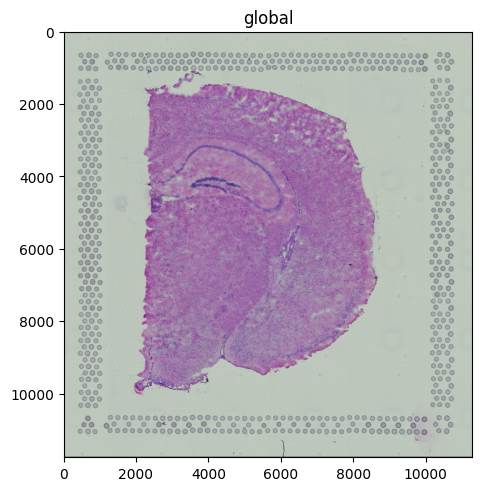

In [4]:
sdata.pl.render_images("hne").pl.show()

## Rendering spots on their own

Visium spots are stored as `shapes`. Rendered alone they show the regular hexagonal capture pattern.

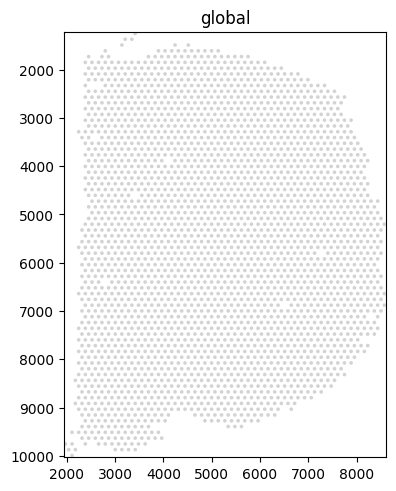

In [5]:
sdata.pl.render_shapes("spots").pl.show()

## Overlay: tissue + spots

The fluent API chains the two renders. Use `fill_alpha` on the spots so the underlying tissue stays visible.

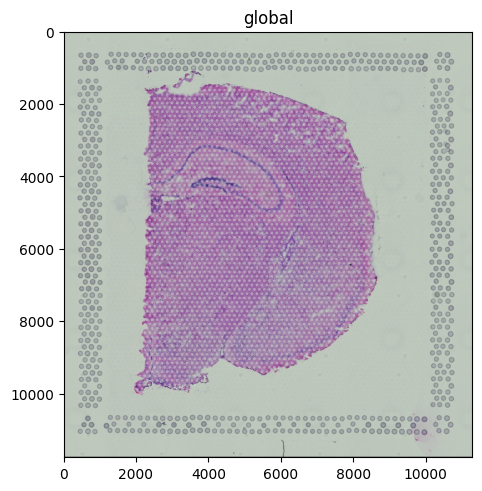

In [17]:
(
    sdata
    .pl.render_images("hne")
    .pl.render_shapes("spots", fill_alpha=0.5)
    .pl.show()
)

## Coloring spots by gene expression

Pass `color=<gene>` to map a column from the linked table onto the spot fill. `Mbp` (Myelin Basic Protein) is a classic white-matter marker; the expression pattern traces the corpus callosum and other myelinated tracts of the brain section.

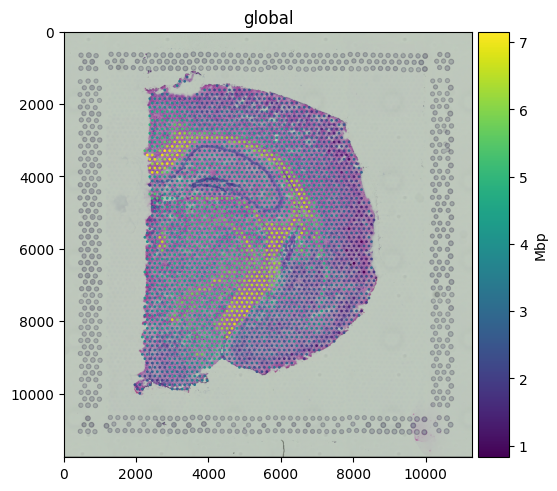

In [16]:
(
    sdata
    .pl.render_images("hne")
    .pl.render_shapes("spots", color="Mbp")
    .pl.show()
)

## Coloring spots by a categorical annotation

`color=` also accepts categorical columns from `obs`. The dataset ships with `cluster` labels from a Leiden clustering run.

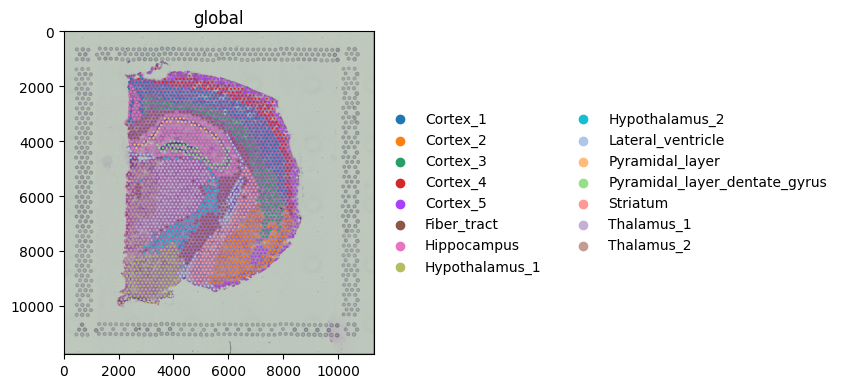

In [20]:
(
    sdata
    .pl.render_images("hne")
    .pl.render_shapes("spots", color="cluster")
    .pl.show(figsize=(4, 6))
)

## Publication-style styling

For a polished figure: keep the tissue context, color the spots by expression with a perceptually uniform colormap, draw a thin outline so the spots stand out against the H&E, and use a translucent fill so the histology underneath stays readable. Furthermore, we'll add a title and a scalebar.

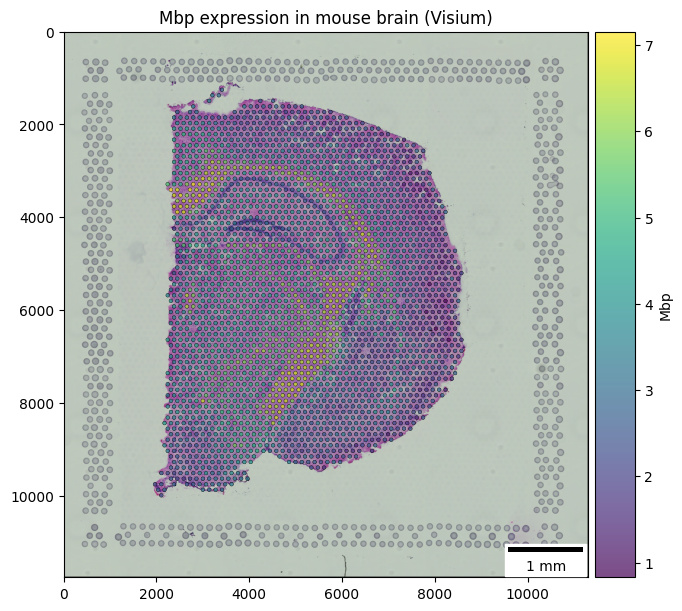

In [27]:
(
    sdata
    .pl.render_images("hne")
    .pl.render_shapes(
        "spots",
        color="Mbp",
        fill_alpha=0.7,
        outline_width=0.4,
        outline_color="black",
        outline_alpha=1.0,
    )
    .pl.show(
        title="Mbp expression in mouse brain (Visium)",
        scalebar_dx=0.615,  # from https://www.10xgenomics.com/datasets/mouse-brain-section-coronal-1-standard-1-1-0
        scalebar_units="um",
        scalebar_params={"location": "lower right"},
        figsize=(6, 6)
    )
)

## For reproducibility

In [28]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import dask
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,scanpy,anndata,squidpy,matplotlib,numpy,pandas,dask,datashader,geopandas,shapely

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.3.4
scanpy          : 1.12.1
anndata         : 0.12.13
squidpy         : 1.8.1
matplotlib      : 3.10.9
numpy           : 2.4.4
pandas          : 2.3.3
dask            : 2026.1.1
datashader      : 0.19.0
geopandas       : 1.1.3
shapely         : 2.1.2

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

